# Plot results for predicting hurricane track (distance) errors.
author: Elizabeth A. Barnes and Randal J. Barnes

In [1]:
import sys
sys.path.append('..')

import sys
sys.path.append('..')

import datetime
import importlib as imp
import os
import pickle
import pprint
import random
import time

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

import tensorflow_probability as tfp
from sklearn import preprocessing
from silence_tensorflow import silence_tensorflow

from build_data import build_hurricane_data
import build_model
import experiment_settings
from save_model_run import save_model_run

In [2]:
__author__ = "Randal J Barnes and Elizabeth A. Barnes"
__version__ = "05 August 2022"

silence_tensorflow()
tf.config.set_visible_devices([], 'GPU') # turn-off tensorflow-metal if it is on

DATA_PATH = "../data/"
MODEL_PATH = "saved_models/"

In [3]:
mpl.rcParams["figure.facecolor"] = "white"
# mpl.rcParams['figure.dpi'] = 300
# mpl.rcParams['savefig.dpi'] = 300
np.warnings.filterwarnings("ignore", category=np.VisibleDeprecationWarning)

In [4]:
EXP_NAME = "bivariate_normal_102_EPCP48"
RNG_SEED = 123
TESTING_YEAR = 2020

In [5]:
# GET PREDICTIONS
settings = experiment_settings.get_settings(EXP_NAME)

network_seed = RNG_SEED
settings['rng_seed'] = RNG_SEED
settings["years_test"] = (TESTING_YEAR,)
(
    data_summary,        
    x_train,
    onehot_train,
    x_val,
    onehot_val,
    x_test,
    onehot_test,        
    x_valtest,
    onehot_valtest,
    df_train,
    df_val,
    df_test,
    df_valtest,
) = build_hurricane_data(DATA_PATH, settings, verbose=2)

# load the model
model_name = (
    EXP_NAME + "_" + 
    str(TESTING_YEAR) + '_' +
    settings["uncertainty_type"] + '_' + 
    f"network_seed_{network_seed}_rng_seed_{settings['rng_seed']}"
)
model = tf.keras.models.load_model(MODEL_PATH + model_name + "_model", compile=False)
y_pred_test = model.predict(x_test)
y_pred_valtest = model.predict(x_valtest)
y_pred_train = model.predict(x_train)

years(2020,) withheld for testing
{'datafile_path': '../data/nnfit_vlist_02-Jun-2022.dat',
 'onehot_test_shape': (123, 5),
 'onehot_train_shape': (1860, 5),
 'onehot_val_shape': (200, 5),
 'onehot_valtest_shape': (323, 5),
 'x_names': ['NCT',
             'VMAX0',
             'AVDX',
             'EMDX',
             'EGDX',
             'HWDX',
             'AVDY',
             'EMDY',
             'EGDY',
             'HWDY',
             'LONC',
             'LATC',
             'VMXC',
             'DV12',
             'SLAT',
             'SHDC',
             'SSTN',
             'DTL'],
 'x_test_shape': (123, 18),
 'x_train_shape': (1860, 18),
 'x_val_shape': (200, 18),
 'x_valtest_shape': (323, 18),
 'y_names': ['OBDX', 'OBDY']}


                     |   cnt |    min |   25% |   50% |   75% |   max |   avg |   std |   iqr
---------------------+-------+--------+-------+-------+-------+-------+-------+-------+-------
 y_train (OBDX [km]) |  1860 | -387.5 | -43.6 |  10.4 |  63.2 

99.39884451277504 109.04745


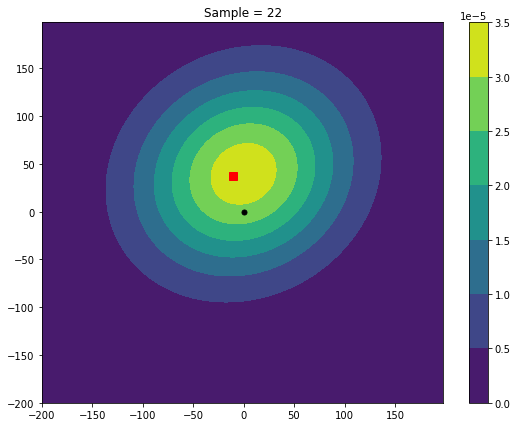

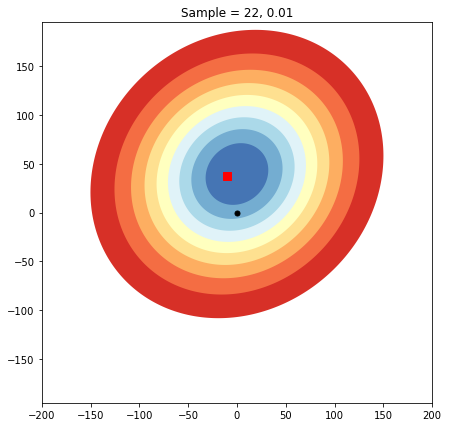

In [26]:
from scipy.stats import multivariate_normal
import mahalanobis
imp.reload(mahalanobis)

sample_plot = 22
mval = 200
inc = 2

mu_u,mu_v,sigma_u,sigma_v,rho = (y_pred_test[sample_plot,0], 
                                 y_pred_test[sample_plot,1], 
                                 y_pred_test[sample_plot,2], 
                                 y_pred_test[sample_plot,3], 
                                 y_pred_test[sample_plot,4],
                                )

cov = np.array([[sigma_u**2, rho*sigma_v*sigma_u], [rho*sigma_v*sigma_u, sigma_v**2]])
rv = multivariate_normal([mu_u, mu_v], cov)

x, y = np.mgrid[-mval:mval:inc, -mval:mval:inc]
grid = np.dstack((x, y))
p = rv.pdf(grid)

plt.figure(figsize=(9,7))
plt.contourf(x,y,p)
plt.plot(0,0,'.k',markersize=10)
plt.plot(onehot_test[sample_plot,0],onehot_test[sample_plot,1],'sr',markersize=8)
plt.title('Sample = ' + str(sample_plot))
plt.colorbar()

error_vec = np.zeros((y_pred_test.shape[0],2))

for isample in np.arange(0,y_pred_test.shape[0]):
    
    mu_u,mu_v,sigma_u,sigma_v,rho = (y_pred_test[isample,0], 
                                     y_pred_test[isample,1], 
                                     y_pred_test[isample,2], 
                                     y_pred_test[isample,3], 
                                     y_pred_test[isample,4],
                                    )    
    cov = np.array([[sigma_u**2, rho*sigma_v*sigma_u], [rho*sigma_v*sigma_u, sigma_v**2]])
    rv = multivariate_normal([mu_u, mu_v], cov)
    
    pred_x, pred_y = (rv.mean[0], rv.mean[1])
    error = [pred_x - onehot_test[isample,0], pred_y - onehot_test[isample,1]]
    
    error_vec[isample] = error
    
rmse = np.sqrt(error_vec[:,0]**2 + error_vec[:,1]**2)
rmse_cons = np.sqrt(onehot_test[:,0]**2 + onehot_test[:,1]**2)
print(rmse.mean(),rmse_cons.mean())


mu_u,mu_v,sigma_u,sigma_v,rho = (y_pred_test[sample_plot,0], 
                                 y_pred_test[sample_plot,1], 
                                 y_pred_test[sample_plot,2], 
                                 y_pred_test[sample_plot,3], 
                                 y_pred_test[sample_plot,4],
                                ) 

plt.figure(figsize=(7,7))
mahalanobis.plot_cdf(mu_u, mu_v, sigma_u, sigma_v, rho)
cdf_val = mahalanobis.compute_cdf(mu_u, mu_v, sigma_u, sigma_v, rho, onehot_test[sample_plot,0],onehot_test[sample_plot,1])
plt.plot(0,0,'.k',markersize=10)
plt.plot(onehot_test[sample_plot,0],onehot_test[sample_plot,1],'sr',markersize=8)
plt.xlim(-200,200)
plt.ylim(-200,200)
plt.title('Sample = ' + str(sample_plot) + ', ' + str(cdf_val.round(2)))

plt.show()

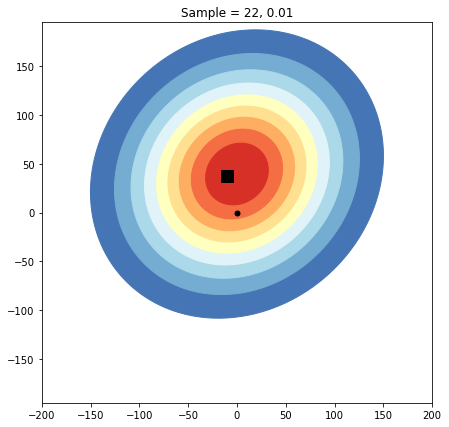

In [71]:
import mahalanobis
imp.reload(mahalanobis)

plt.figure(figsize=(7,7))
mahalanobis.plot_cdf(mu_u, 
                     mu_v, 
                     sigma_u, 
                     sigma_v, 
                     rho,
                     label_u=onehot_test[sample_plot,0],
                     label_v=onehot_test[sample_plot,1],
                    )
cdf_val = mahalanobis.compute_cdf(mu_u, mu_v, sigma_u, sigma_v, rho, onehot_test[sample_plot,0],onehot_test[sample_plot,1])
plt.xlim(-200,200)
plt.ylim(-200,200)
plt.title('Sample = ' + str(sample_plot) + ', ' + str(cdf_val.round(2)))

plt.show()

(array([17., 26., 24., 21., 12., 11.,  3.,  2.,  2.,  5.]),
 array([-0.05289119, -0.00699067,  0.03890985,  0.08481037,  0.13071088,
         0.17661141,  0.22251193,  0.26841244,  0.31431296,  0.3602135 ,
         0.406114  ], dtype=float32),
 <BarContainer object of 10 artists>)

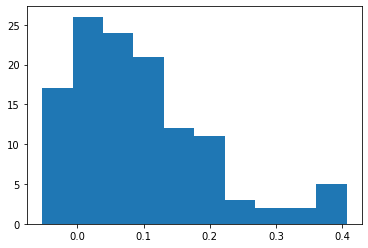

In [7]:
plt.hist(y_pred_test[:,4])

0.024142775077192376 0.016692446522239716


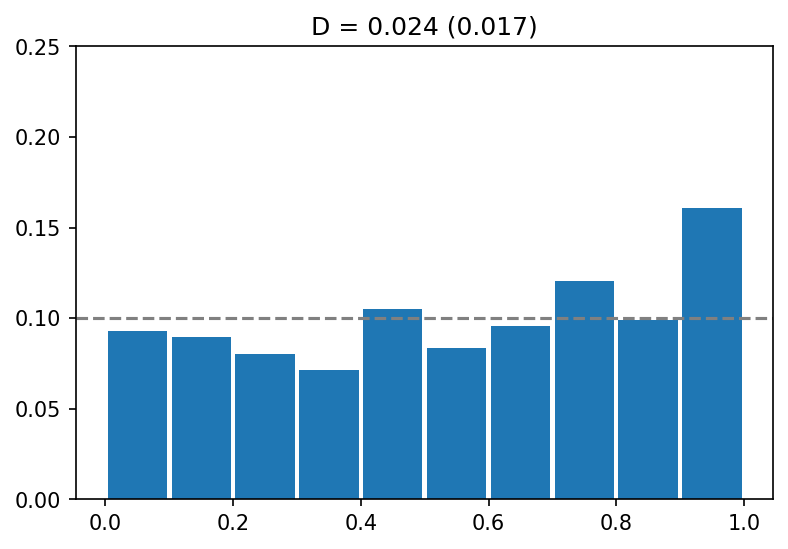

In [8]:
bins = np.linspace(0, 1, 11)
bins_inc = bins[1]-bins[0]

y_data = y_pred_valtest
onehot_data = onehot_valtest

F = mahalanobis.compute_cdf(y_data[:,0], 
                            y_data[:,1], 
                            y_data[:,2], 
                            y_data[:,3], 
                            y_data[:,4], 
                            onehot_data[:,0], 
                            onehot_data[:,1],
                           )
pit_hist = np.histogram(F,
                        bins,
                        weights=np.ones_like(F)/float(len(F)),
                         )

B   = len(pit_hist[0])
D   = np.sqrt(1/B * np.sum( (pit_hist[0] - 1/B)**2 ))
EDp = np.sqrt( (1.-1/B) / (onehot_data.shape[0]*B) )
print(D, EDp)
# F = dist.cdf(onehot_data[:,0])

bin_width = bins_inc/1.075
bin_add = bins_inc/2

plt.figure(dpi=150)
plt.bar(pit_hist[1][:-1] + bin_add,
 pit_hist[0],
 width=bin_width,
)
plt.axhline(y=0.1,linestyle='--',color='gray')
plt.ylim(0,.25)
plt.title('D = ' + str(D.round(3)) + ' (' + str(EDp.round(3)) + ')')

plt.show()

In [9]:
error('here')

TypeError: 'list' object is not callable

# Plots

In [ ]:
N_COLORS = 50
colors = ('#D95980','#284E60','#284E60','#C3B1E1','#351F27','#A9C961')

### for white background...
plt.rc('text',usetex=True)
plt.rc('font',**{'family':'sans-serif','sans-serif':['Avant Garde']}) 
plt.rc('savefig',facecolor='white')
plt.rc('axes',facecolor='white')
plt.rc('axes',labelcolor='dimgrey')
plt.rc('axes',labelcolor='dimgrey')
plt.rc('xtick',color='dimgrey')
plt.rc('ytick',color='dimgrey')
################################  
################################  
def adjust_spines(ax, spines):
    for loc, spine in ax.spines.items():
        if loc in spines:
            spine.set_position(('outward', 5))
        else:
            spine.set_color('none')  
    if 'left' in spines:
        ax.yaxis.set_ticks_position('left')
    else:
        ax.yaxis.set_ticks([])
    if 'bottom' in spines:
        ax.xaxis.set_ticks_position('bottom')
    else:
            ax.xaxis.set_ticks([]) 
            
def format_spines(ax):
    adjust_spines(ax, ['left', 'bottom'])
    ax.spines['top'].set_color('none')
    ax.spines['right'].set_color('none')
    ax.spines['left'].set_color('dimgrey')
    ax.spines['bottom'].set_color('dimgrey')
    ax.spines['left'].set_linewidth(2)
    ax.spines['bottom'].set_linewidth(2)
    ax.tick_params('both',length=4,width=2,which='major',color='dimgrey')
#     ax.yaxis.grid(zorder=1,color='dimgrey',alpha=0.35)                

In [ ]:
def plot_iqr_vs_error(ax, model, x_eval, onehot_eval, df_eval, yvar="shash_error"):
    # make predictions
    mu_pred, sigma_pred, gamma_pred, tau_pred = prediction.params(x_eval, model)    

    # convert y_pred to intensity corrections    
    ann_correction  = prediction.percentile_value(mu_pred,sigma_pred,gamma_pred,tau_pred,percentile_frac=.5)
    true_correction = df_eval['OBDV'].to_numpy()  

    # convert to full intensity predictions
    cons_intensity  = df_eval['VMXC'].to_numpy()
    ann_intensity   = cons_intensity + ann_correction
    true_intensity  = cons_intensity + true_correction

    # compute errors
    shash_error  = np.abs(ann_intensity - true_intensity)
    cons_error = np.abs(cons_intensity - true_intensity)

    # covert shash prediction bounds
    shash_low_correction  = prediction.percentile_value(mu_pred,sigma_pred,gamma_pred,tau_pred,percentile_frac=.25)
    shash_high_correction = prediction.percentile_value(mu_pred,sigma_pred,gamma_pred,tau_pred,percentile_frac=.75)
    iqr                   = shash_high_correction - shash_low_correction

    print(stats.spearmanr(iqr,shash_error))
    print(stats.pearsonr(iqr,shash_error))

    df_eval['iqr'] = iqr
    df_eval['shash_error'] = shash_error
    df_eval['cons_error'] = cons_error

    #------------------------------------------------------------------------------------
    ROUND_BASE = 50

    df_plot = df_eval.copy()
    df_plot['iqr'] = pd.Series(df_plot['iqr']).apply(lambda x: custom_round(x, base=ROUND_BASE))
    df_plot['iqr'] = pd.Series(df_plot['iqr']).apply(lambda x: ceiling_round(x, ceiling=200))
    #-----------------------------------------------------------------------------
    clr = colors[0]
    if(yvar=="cons_error"):
        clr =colors[1]
    
    for xvar in ('iqr',):#('sigma', 'range_66'):
        g = sns.boxplot(
            ax=ax,
            data=df_plot,
            x=xvar, y=yvar,
            whis=None,
            fliersize=0,
            boxprops={'alpha':.2,
                      'edgecolor': 'gray',
                      'color': 'gray',
                     },
        )      
        plt.setp(g.artists, edgecolor = '.4', facecolor='.95')
        plt.setp(g.lines, color='.4')
        ax = sns.stripplot(ax=ax,x=xvar, y=yvar, data=df_plot, color=clr, size=3.,alpha=.75,)
        # plt.axhline(y=0,color='k', alpha=.25, linewidth=1)

        # g.set_xlim(-.5,6.5)

        ax.set_xlabel('Predicted IQR [km]')
        if(yvar=="cons_error"):
            ax.set_title('(b) Consensus Error vs SHASH Predicted Uncertainty', fontsize=FS*.9, color='k')    
            ax.set_ylabel('Absolute Error [km]')
        else:
            ax.set_title('(a) SHASH Error vs SHASH Predicted Uncertainty', fontsize=FS*.9, color='k')            
            ax.set_ylabel('Absolute Error [km]')        



## Latitude + Longitude

In [ ]:
data = np.concatenate((
                       mu_pred_dx[:,np.newaxis], 
                       sigma_pred_dx[:,np.newaxis], 
                       gamma_pred_dx[:,np.newaxis],           
                       tau_pred_dx[:,np.newaxis],

                       mu_pred_dy[:,np.newaxis], 
                       sigma_pred_dy[:,np.newaxis], 
                       gamma_pred_dy[:,np.newaxis],           
                       tau_pred_dy[:,np.newaxis],

                       iqr_diag[:,np.newaxis],
                       
                       ann_error[:,np.newaxis],
                       cons_error[:,np.newaxis],
                       
                       ann_low_correction_dx[:,np.newaxis],
                       ann_high_correction_dx[:,np.newaxis],
                       ann_low_correction_dy[:,np.newaxis],
                       ann_high_correction_dy[:,np.newaxis],
                       
                       iqr_dx[:,np.newaxis],
                       iqr_dy[:,np.newaxis],
                       
                      ),
                      axis=1)

all_names = []#data_summary['x_names'].copy()
for a in ('mu_pred_dx', 
          'sigma_pred_dx', 
          'gamma_pred_dx', 
          'tau_pred_dx', 
          'mu_pred_dy', 
          'sigma_pred_dy', 
          'gamma_pred_dy', 
          'tau_pred_dy',          
          'iqr_diag', 
          'ann_error', 
          'cons_error',
          'ann_low_correction_dx',
          'ann_high_correction_dx',
          'ann_low_correction_dy',
          'ann_high_correction_dy',   
          'iqr_dx',
          'iqr_dy',
         ):
    all_names.append(a)
df = pd.DataFrame(data=data, columns=all_names)

## Single Latitude / Longitude

In [ ]:
import model_diagnostics
FS = 12

cmap_interp = cm.get_cmap('RdBu_r', N_COLORS)    
norm = mpl.colors.Normalize(vmin=0, vmax=10)

fig = plt.figure(figsize=(12, 3.))
spec = fig.add_gridspec(1,2)

for itype,track_type in enumerate(('latitude','longitude')):
    
    if track_type == 'latitude':
        x_data = x_valtest_dy
        onehot = onehot_valtest_dy
        model = model_dy        
    elif track_type == 'longitude':
        x_data = x_valtest_dx     
        onehot = onehot_valtest_dx
        model = model_dx
    
    bins, hist_shash, D_shash, EDp_shash = model_diagnostics.compute_pit('shash',onehot, x_data=x_data,model_shash=model)
    bins_inc = bins[1]-bins[0]
    
    ax = fig.add_subplot(spec[0,itype])
    for ibar in np.arange(0,len(bins)-1):
        plt.bar(bins[ibar]+bins_inc/2,
                 hist_shash[0][ibar],
                 width=bins_inc*.98,
                 color=cmap_interp(norm(ibar)),
                 label='SHASH',
                )
    ax.axhline(y=.1, 
                linestyle='--',
                color='dimgray', 
                linewidth=2.,
               )
    plt.ylim(0,.2)
    plt.xticks(bins,np.around(bins,1))
    ax = plt.gca()
    yticks = np.around(np.arange(0,.25,.05),2)
    plt.yticks(yticks,yticks)

    plt.text(1.,np.max(yticks)*.9,
             'D: ' + str(np.round(D_shash,4)) + ' (' + str(np.round(EDp_shash,3)) +  ')', 
             color='dimgray',     
             verticalalignment='top',
             horizontalalignment='right',
             fontsize=10)


    plt.xlabel('probability integral transform')
    plt.ylabel('probability')
    plt.title(track_type, fontsize=FS, color='k')

    format_spines(ax)
    plt.text(.5, .995, MODEL_NAME,
        horizontalalignment='center',
        verticalalignment='top',
        color='tab:gray',
        fontsize=5,
        transform = ax.transAxes)        
    
plt.savefig(FIGURE_PATH + 'pit_' + MODEL_NAME + '.png', dpi=dpiFig, bbox_inches='tight')        


In [ ]:
index = 164
bound = 400
scale = 10_000

#----------------------------------------------------------------
MS = 10
plt.figure(figsize=(6,5))
ax = plt.subplot(111)
format_spines(ax)

plt.plot(0,0,'.', color='orange', markersize=MS, label='Consensus')
plt.annotate("Consensus", (0,0), color='orange', xytext=(-5,5), textcoords='offset pixels', horizontalalignment='right')

plt.plot(true_correction_dx[index],true_correction_dy[index],'.',color='mediumblue', markersize=MS, label='Truth')
plt.annotate("Truth", (true_correction_dx[index],true_correction_dy[index]), color='mediumblue', xytext=(-2.5,-2.5), textcoords='offset pixels',horizontalalignment='right', verticalalignment='top')

plt.plot(ann_correction_dx[index],ann_correction_dy[index],'.', color='deeppink', markersize=MS, label='ANN')
plt.annotate("ANN", (ann_correction_dx[index],ann_correction_dy[index]), color='deeppink', xytext=(5,5), textcoords='offset pixels')

plt.plot((ann_low_correction_dx[index],ann_high_correction_dx[index]),(ann_low_correction_dy[index],ann_low_correction_dy[index]),'-', color='deeppink')
plt.plot((ann_low_correction_dx[index],ann_high_correction_dx[index]),(ann_high_correction_dy[index],ann_high_correction_dy[index]),'-', color='deeppink')
plt.plot((ann_low_correction_dx[index],ann_low_correction_dx[index]),(ann_low_correction_dy[index],ann_high_correction_dy[index]),'-', color='deeppink')
plt.plot((ann_high_correction_dx[index],ann_high_correction_dx[index]),(ann_low_correction_dy[index],ann_high_correction_dy[index]),'-', color='deeppink')

plt.fill([ann_low_correction_dx[index], 
          ann_high_correction_dx[index], 
          ann_high_correction_dx[index], 
          ann_low_correction_dx[index], 
          ann_low_correction_dx[index]], 
         [ann_low_correction_dy[index], 
          ann_low_correction_dy[index], 
          ann_high_correction_dy[index], 
          ann_high_correction_dy[index], 
          ann_low_correction_dy[index]
         ],color='deeppink',alpha=.1)

plt.xlim(-bound,bound)
plt.ylim(-bound,bound)

# plot the x-direction PDF
x = np.arange(-1000,1000)
shash_dist = shash_tfp.Shash(df['mu_pred_dx'][index], 
                       df['sigma_pred_dx'][index], 
                       df['gamma_pred_dx'][index], 
                       df['tau_pred_dx'][index],
                      )
d = -bound + scale*shash_dist.prob(x)
plt.plot(x,d,'-',color='deeppink')
x_shade = np.logical_and((x>=df['ann_low_correction_dx'][index]), (x<=df['ann_high_correction_dx'][index]))
plt.fill_between(x,d,-bound,x_shade, color='deeppink',alpha=.1)
plt.annotate("- 50\% -", (df['ann_low_correction_dx'][index]+df['iqr_dx'][index]/2,-bound), color='deeppink', alpha=.5,xytext=(0,5), fontsize=6, textcoords='offset pixels',horizontalalignment='center', verticalalignment='bottom')


# plot the y-direction PDF
x = np.arange(-1000,1000)
shash_dist = shash_tfp.Shash(df['mu_pred_dy'][index], 
                       df['sigma_pred_dy'][index], 
                       df['gamma_pred_dy'][index], 
                       df['tau_pred_dy'][index],
                      )
d = bound - scale*shash_dist.prob(x)
plt.plot(d,x,'-',color='deeppink')
x_shade = np.logical_and((x>=df['ann_low_correction_dy'][index]), (x<=df['ann_high_correction_dy'][index]))
plt.fill_betweenx(x,d,bound,x_shade, color='deeppink',alpha=.1)
plt.annotate("- 50\% -", (bound,df['ann_low_correction_dy'][index]+df['iqr_dy'][index]/2), color='deeppink', alpha=.5,xytext=(-5,0), fontsize=6, textcoords='offset pixels',horizontalalignment='right', verticalalignment='center', rotation=90)


plt.xlabel('track X correction [km] ')
plt.ylabel('track Y correction [km]')

ax = plt.gca()
plt.text(.5, .995, 'validation sample = \#' + str(index) + '\n' + MODEL_NAME,
    horizontalalignment='center',
    verticalalignment='top',
    color='tab:gray',
    fontsize=5,
    transform = ax.transAxes)    

plt.savefig(FIGURE_PATH + 'prediction_map_sample' + str(index) + '_' + MODEL_NAME + '.png', dpi=dpiFig)    
plt.show()

# df_dx.iloc[index]

In [ ]:
bound = 500
scale = 10_000

#----------------------------------------------------------------
MS = 10
plt.figure(figsize=(6,5))
ax = plt.subplot(111)
format_spines(ax)

plt.plot(0,0,'.', color='orange', markersize=MS, label='Consensus')

plt.plot(true_correction_dx,true_correction_dy,'.',color='mediumblue', markersize=MS, label='Truth')

plt.plot(ann_correction_dx,ann_correction_dy,'.', color='deeppink', markersize=MS, label='ANN')



plt.xlim(-bound,bound)
plt.ylim(-bound,bound)


plt.xlabel('track X correction [km] ')
plt.ylabel('track Y correction [km]')

ax = plt.gca()
plt.text(.5, .995, 'validation sample = \#' + str(index) + '\n' + MODEL_NAME,
    horizontalalignment='center',
    verticalalignment='top',
    color='tab:gray',
    fontsize=5,
    transform = ax.transAxes)    

# plt.savefig(FIGURE_PATH + 'prediction_map_sample' + str(index) + '_' + MODEL_NAME + '.png', dpi=dpiFig)    
plt.show()

# df_dx.iloc[index]

In [ ]:
plt.subplot(1,2,1)
plt.hist(ann_correction_dx)

plt.subplot(1,2,2)
plt.hist(ann_correction_dy)


plt.show()

### Errors vs uncertainty estimates

In [ ]:
def plot_iqr_vs_error(ax, model, x_eval, onehot_eval, df_eval, yvar="shash_error"):
    # make predictions
    mu_pred, sigma_pred, gamma_pred, tau_pred = prediction.params(x_eval, model)    

    # convert y_pred to intensity corrections    
    ann_correction  = prediction.percentile_value(mu_pred,sigma_pred,gamma_pred,tau_pred,percentile_frac=.5)
    true_correction =  onehot_eval[:,0]

    # compute errors
    shash_error  = np.abs(ann_correction - true_correction)

    # covert shash prediction bounds
    shash_low_correction  = prediction.percentile_value(mu_pred,sigma_pred,gamma_pred,tau_pred,percentile_frac=.25)
    shash_high_correction = prediction.percentile_value(mu_pred,sigma_pred,gamma_pred,tau_pred,percentile_frac=.75)
    iqr                   = shash_high_correction - shash_low_correction

    print(stats.spearmanr(iqr,shash_error))
    print(stats.pearsonr(iqr,shash_error))

    df_eval['iqr'] = iqr
    df_eval['shash_error'] = shash_error

    #------------------------------------------------------------------------------------
    ROUND_BASE = 50

    df_plot = df_eval.copy()
    df_plot['iqr'] = pd.Series(df_plot['iqr']).apply(lambda x: custom_round(x, base=ROUND_BASE))
    df_plot['iqr'] = pd.Series(df_plot['iqr']).apply(lambda x: ceiling_round(x, ceiling=200))
    #-----------------------------------------------------------------------------
    clr = colors[0]
    
    for xvar in ('iqr',):#('sigma', 'range_66'):
        g = sns.boxplot(
            ax=ax,
            data=df_plot,
            x=xvar, y=yvar,
            whis=None,
            fliersize=0,
            boxprops={'alpha':.2,
                      'edgecolor': 'gray',
                      'color': 'gray',
                     },
        )      
        plt.setp(g.artists, edgecolor = '.4', facecolor='.95')
        plt.setp(g.lines, color='.4')
        ax = sns.stripplot(ax=ax,x=xvar, y=yvar, data=df_plot, color=clr, size=3.,alpha=.75,)
        # plt.axhline(y=0,color='k', alpha=.25, linewidth=1)

        # g.set_xlim(-.5,6.5)

        ax.set_xlabel('Predicted IQR [km]')
        ax.set_title('(a) SHASH Error vs SHASH Predicted Uncertainty', fontsize=FS*.9, color='k')            
        ax.set_ylabel('Absolute Error [km]')        



In [ ]:
from toolbox import custom_round, ceiling_round

f, axs = plt.subplots(1, 2, figsize=(16,5))

# latitude
ax = axs[0]
plot_iqr_vs_error(ax, model_dy, x_valtest_dy, onehot_valtest_dy, df_valtest_dy, yvar="shash_error")
plt.text(.995, .995, MODEL_NAME,
    horizontalalignment='right',
    verticalalignment='top',
    color='tab:gray',
    fontsize=5,
    transform = ax.transAxes)    
ax.set_title('latitude')

# longitude
ax = axs[1]
plot_iqr_vs_error(ax, model_dx, x_valtest_dx, onehot_valtest_dx, df_valtest_dx, yvar="shash_error")
plt.text(.995, .995, MODEL_NAME,
    horizontalalignment='right',
    verticalalignment='top',
    color='tab:gray',
    fontsize=5,
    transform = ax.transAxes)   
ax.set_title('longitude')


plt.savefig(FIGURE_PATH + 'error_vs_uq_boxplot_' +  MODEL_NAME + '.png', dpi=dpiFig)    
plt.show()

### ANN prediction of Consensus Error

In [ ]:
import scipy.stats as stats

if(EXP_NAME_dx[-2:]=='72'):
    bound=625
    inc = .000005
else:
    bound=375
    inc = .00002


plt.figure(figsize=(5,5))
ax = plt.gca()
adjust_spines(ax, ['left', 'bottom'])
ax.spines['top'].set_color('none')
ax.spines['right'].set_color('none')
ax.spines['left'].set_color('dimgrey')
ax.spines['bottom'].set_color('dimgrey')
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.tick_params('both',length=4,width=2,which='major',color='dimgrey')

# Peform the kernel density estimate
x = df['cons_error']
y = df['ann_error']
xmin, xmax = -1000, 1000
ymin, ymax = -1000, 1000

xx, yy = np.mgrid[xmin:xmax:500j, ymin:ymax:500j]
positions = np.vstack([xx.ravel(), yy.ravel()])
values = np.vstack([x, y])
kernel = stats.gaussian_kde(values,bw_method='scott')
f = np.reshape(kernel(positions).T, xx.shape)


cfset = plt.contour(xx, yy, f, levels=np.arange(inc,.0005,inc), colors='purple', alpha=.7)
plt.plot((0,1000),(0,1000),'-',color='orange',linewidth=3.)
plt.annotate("one-to-one", (bound*.75,bound*.75), color='orange', alpha=1.,xytext=(-25,0), fontsize=10, textcoords='offset pixels',horizontalalignment='left', verticalalignment='bottom', rotation=45)
plt.plot(df['cons_error'],df['ann_error'],'.',color='purple',alpha=.25)

plt.xlim(-0.01*bound,bound)
plt.ylim(-0.01*bound,bound)

plt.annotate("ANN is closer", (bound*.75,bound*.25), color='orange', alpha=1.,xytext=(0,0), fontsize=10, textcoords='offset pixels',horizontalalignment='center', verticalalignment='center')
plt.annotate("Consensus is closer", (bound*.25,bound*.75), color='orange', alpha=1.,xytext=(0,0), fontsize=10, textcoords='offset pixels',horizontalalignment='center', verticalalignment='center')

plt.ylabel('ANN track error [km]')
plt.xlabel('Consensus track error [km]')
plt.title('TRACK Errors')

plt.text(.5, .995, MODEL_NAME,
    horizontalalignment='center',
    verticalalignment='top',
    color='tab:gray',
    fontsize=5,
    transform = ax.transAxes)    

t = 'ANN MAE from Obs           = ' + str(np.round(ann_mae,1)) + '\nConsensus MAE from Obs = ' + str(np.round(cons_mae,1))
plt.text(.01,.95,t,
    horizontalalignment='left',
    verticalalignment='top',
    color='tab:gray',
    fontsize=8,
    transform = ax.transAxes)  

ax.set_aspect('equal')

plt.tight_layout()
plt.savefig(FIGURE_PATH + 'prediction_vs_actual_' + MODEL_NAME + '.png', dpi=dpiFig)    
plt.show()